## ColorSegmenter

In [1]:
import cv2
import numpy as np

# Load the image
image = cv2.imread('plant_image5.jpg')  # Replace with your image path
image = cv2.resize(image, (750, 1000))  # Resize for better visualization
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Function to update mask based on trackbar values
def update_mask(val):
    lower_h = cv2.getTrackbarPos('Lower H', 'HSV Adjustments')
    lower_s = cv2.getTrackbarPos('Lower S', 'HSV Adjustments')
    lower_v = cv2.getTrackbarPos('Lower V', 'HSV Adjustments')
    upper_h = cv2.getTrackbarPos('Upper H', 'HSV Adjustments')
    upper_s = cv2.getTrackbarPos('Upper S', 'HSV Adjustments')
    upper_v = cv2.getTrackbarPos('Upper V', 'HSV Adjustments')

    # Define lower and upper HSV values
    lower_bound = np.array([lower_h, lower_s, lower_v])
    upper_bound = np.array([upper_h, upper_s, upper_v])

    # Apply mask
    mask = cv2.inRange(hsv, lower_bound, upper_bound)
    result = cv2.bitwise_and(image, image, mask=mask)

    # Display results
    cv2.imshow('Masked Image', mask)
    cv2.imshow('Segmented Image', result)

# Create a window
cv2.namedWindow('HSV Adjustments')

# Create trackbars for HSV adjustments
cv2.createTrackbar('Lower H', 'HSV Adjustments', 25, 179, lambda x: None)
cv2.createTrackbar('Lower S', 'HSV Adjustments', 40, 255, lambda x: None)
cv2.createTrackbar('Lower V', 'HSV Adjustments', 40, 255, lambda x: None)
cv2.createTrackbar('Upper H', 'HSV Adjustments', 90, 179, lambda x: None)
cv2.createTrackbar('Upper S', 'HSV Adjustments', 255, 255, lambda x: None)
cv2.createTrackbar('Upper V', 'HSV Adjustments', 255, 255, lambda x: None)

# Loop to keep the trackbar window running
while True:
    update_mask(0)  # Update the mask dynamically
    key = cv2.waitKey(1) & 0xFF
    if key == 27:  # Press 'Esc' to exit
        break

cv2.destroyAllWindows()


This Python code provides a practical demonstration of color-based image segmentation using OpenCV. By leveraging the HSV color space and interactive trackbars, it empowers users to dynamically isolate specific color ranges within an image. 

The script begins by loading and preprocessing an image, converting it to HSV for easier color manipulation. The core functionality lies within the update_mask function, which creates a binary mask based on user-defined HSV thresholds, effectively highlighting pixels within the desired color range. The resulting mask is then applied to the original image, producing a segmented output that showcases only the selected colors. Through the intuitive interface of trackbars, users can refine the HSV bounds in real-time, observing the impact on the segmentation. This interactive approach makes the code a valuable tool for tasks such as object detection, image filtering, and isolating specific color regions, offering a hands-on experience with fundamental image processing techniques.

### Converting height measured in pixels to centimeters using a known plant height

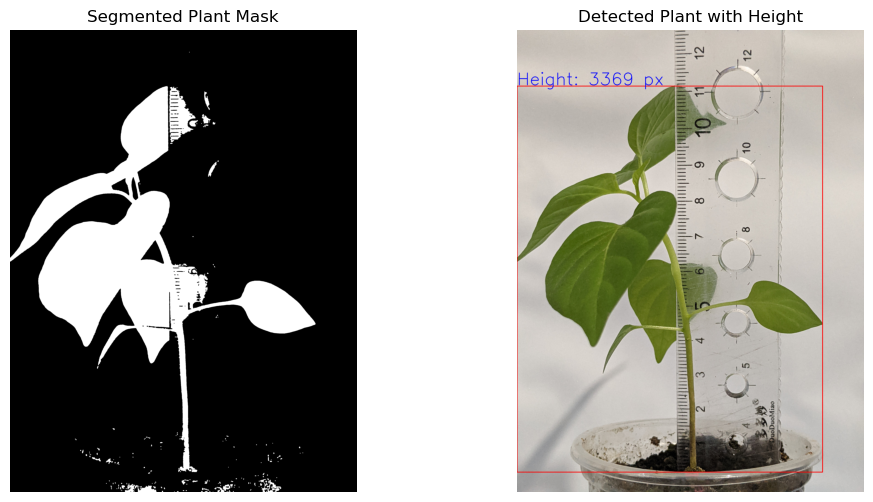

Plant Height: 3369 pixels
Plant Height: 11.20 cm


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('plant_image5.jpg')  # Replace with your image path
#image = cv2.resize(image, (900, 1200))  # Resize for better visualization

# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define HSV range for green color (adjust if needed)
lower_green = np.array([18, 62, 62])  # Lower HSV threshold
upper_green = np.array([55, 255, 186])  # Upper HSV threshold

# Create mask for green areas (plant)
mask = cv2.inRange(hsv, lower_green, upper_green)

# Apply morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Find the largest contour (assumed to be the plant)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box around the plant
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw bounding box
    result = image.copy()
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 5)

    # Display the height of the plant
    cv2.putText(result, f"Height: {h} px", (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 6)

    # Convert images to RGB for matplotlib
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Segmented Plant Mask')
    axes[0].axis('off')
    
    axes[1].imshow(result_rgb)
    axes[1].set_title('Detected Plant with Height')
    axes[1].axis('off')
    
    plt.show()
    
    x = h * 0.00332442861383199762540813297714
    print(f"Plant Height: {h} pixels")
    print(f"Plant Height: {x:.2f} cm")
else:
    print("No plant detected!")


We know the height of the plant above, and we get the height of the same plant in pixels, and based on that height, we get the ratio between the actual height of the plant and the pixel count. Using that, we calculate the height of the other plants.

These are approximate values, and we tried to always keep the distance between the plant and the camera uniform.

Depending on the distance between the camera and the plant, the pixel value captured by the camera on the plant changes.

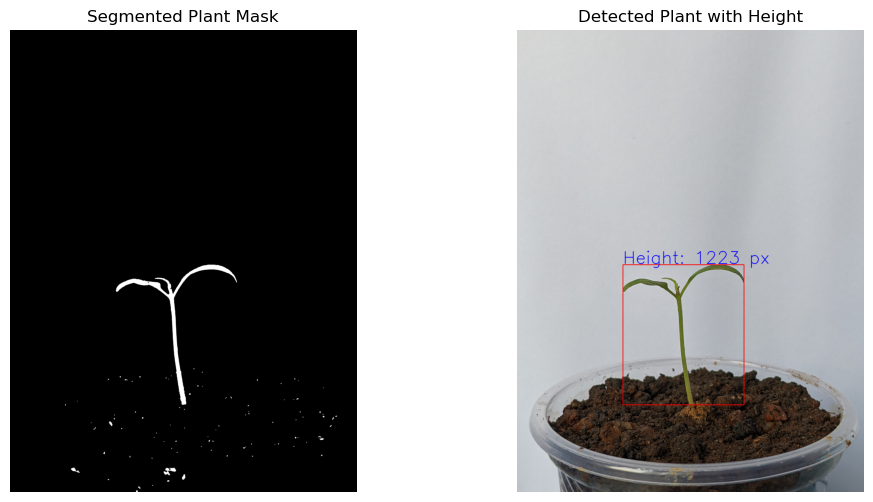

Plant Height: 1223 pixels
Plant Height: 4.07 cm


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('plant_image.jpg')  # Replace with your image path
#image = cv2.resize(image, (900, 1200))  # Resize for better visualization

# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define HSV range for green color (adjust if needed)
lower_green = np.array([18, 62, 62])  # Lower HSV threshold
upper_green = np.array([55, 255, 186])  # Upper HSV threshold

# Create mask for green areas (plant)
mask = cv2.inRange(hsv, lower_green, upper_green)

# Apply morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Find the largest contour (assumed to be the plant)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box around the plant
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw bounding box
    result = image.copy()
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 5)

    # Display the height of the plant
    cv2.putText(result, f"Height: {h} px", (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 6)

    # Convert images to RGB for matplotlib
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Segmented Plant Mask')
    axes[0].axis('off')
    
    axes[1].imshow(result_rgb)
    axes[1].set_title('Detected Plant with Height')
    axes[1].axis('off')
    
    plt.show()
    
    x = h * 0.00332442861383199762540813297714
    print(f"Plant Height: {h} pixels")
    print(f"Plant Height: {x:.2f} cm")
else:
    print("No plant detected!")


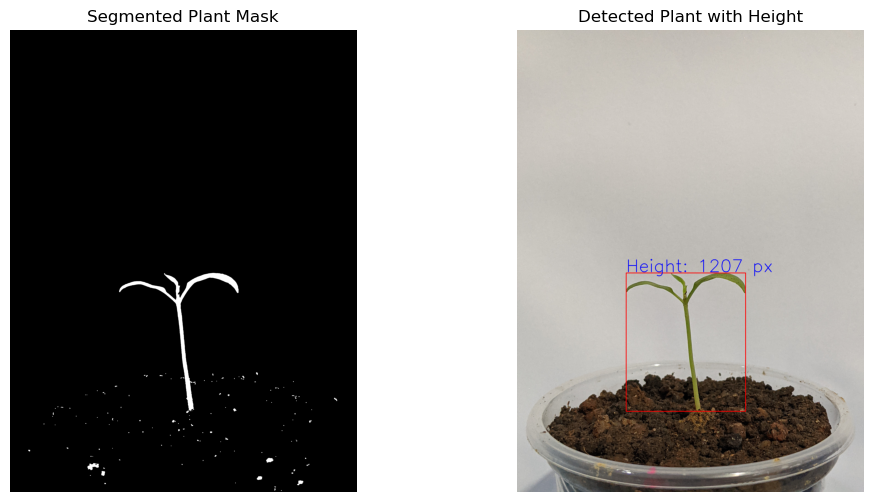

Plant Height: 1207 pixels
Plant Height: 4.01 cm


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('plant_image2.jpg')  # Replace with your image path
#image = cv2.resize(image, (900, 1200))  # Resize for better visualization

# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define HSV range for green color (adjust if needed)
lower_green = np.array([18, 62, 62])  # Lower HSV threshold
upper_green = np.array([55, 255, 186])  # Upper HSV threshold

# Create mask for green areas (plant)
mask = cv2.inRange(hsv, lower_green, upper_green)

# Apply morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Find the largest contour (assumed to be the plant)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box around the plant
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw bounding box
    result = image.copy()
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 5)

    # Display the height of the plant
    cv2.putText(result, f"Height: {h} px", (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 6)

    # Convert images to RGB for matplotlib
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Segmented Plant Mask')
    axes[0].axis('off')
    
    axes[1].imshow(result_rgb)
    axes[1].set_title('Detected Plant with Height')
    axes[1].axis('off')
    
    plt.show()
    
    x = h * 0.00332442861383199762540813297714
    print(f"Plant Height: {h} pixels")
    print(f"Plant Height: {x:.2f} cm")
else:
    print("No plant detected!")


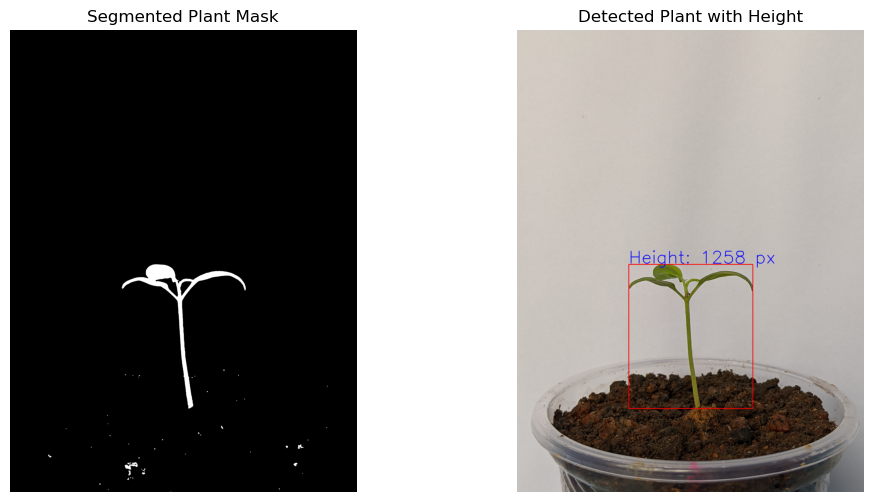

Plant Height: 1258 pixels
Plant Height: 4.18 cm


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('plant_image3.jpg')  # Replace with your image path
#image = cv2.resize(image, (900, 1200))  # Resize for better visualization

# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define HSV range for green color (adjust if needed)
lower_green = np.array([18, 62, 62])  # Lower HSV threshold
upper_green = np.array([55, 255, 186])  # Upper HSV threshold

# Create mask for green areas (plant)
mask = cv2.inRange(hsv, lower_green, upper_green)

# Apply morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Find the largest contour (assumed to be the plant)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box around the plant
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw bounding box
    result = image.copy()
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 5)

    # Display the height of the plant
    cv2.putText(result, f"Height: {h} px", (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 6)

    # Convert images to RGB for matplotlib
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Segmented Plant Mask')
    axes[0].axis('off')
    
    axes[1].imshow(result_rgb)
    axes[1].set_title('Detected Plant with Height')
    axes[1].axis('off')
    
    plt.show()
    
    x = h * 0.00332442861383199762540813297714
    print(f"Plant Height: {h} pixels")
    print(f"Plant Height: {x:.2f} cm")
else:
    print("No plant detected!")


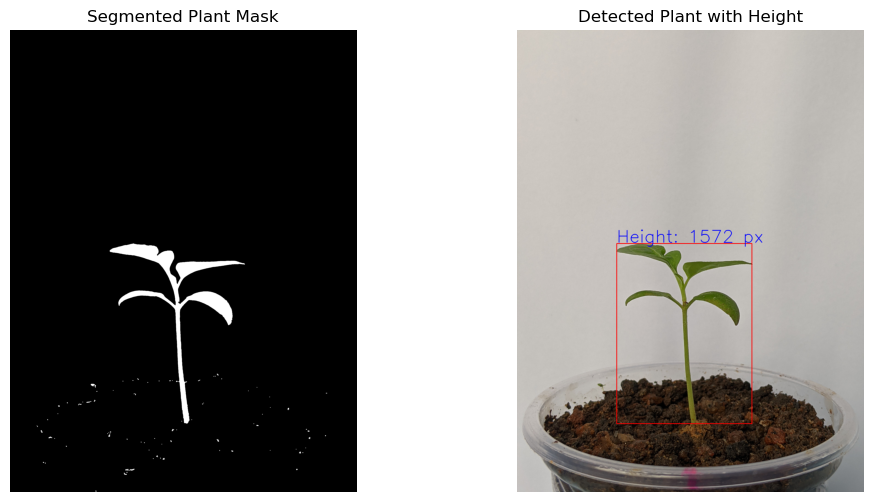

Plant Height: 1572 pixels
Plant Height: 5.23 cm


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('plant_image4.jpg')  # Replace with your image path
#image = cv2.resize(image, (900, 1200))  # Resize for better visualization

# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define HSV range for green color (adjust if needed)
lower_green = np.array([18, 62, 62])  # Lower HSV threshold
upper_green = np.array([55, 255, 186])  # Upper HSV threshold

# Create mask for green areas (plant)
mask = cv2.inRange(hsv, lower_green, upper_green)

# Apply morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Find the largest contour (assumed to be the plant)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box around the plant
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw bounding box
    result = image.copy()
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 5)

    # Display the height of the plant
    cv2.putText(result, f"Height: {h} px", (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 6)

    # Convert images to RGB for matplotlib
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Segmented Plant Mask')
    axes[0].axis('off')
    
    axes[1].imshow(result_rgb)
    axes[1].set_title('Detected Plant with Height')
    axes[1].axis('off')
    
    plt.show()
    
    x = h * 0.00332442861383199762540813297714
    print(f"Plant Height: {h} pixels")
    print(f"Plant Height: {x:.2f} cm")
else:
    print("No plant detected!")


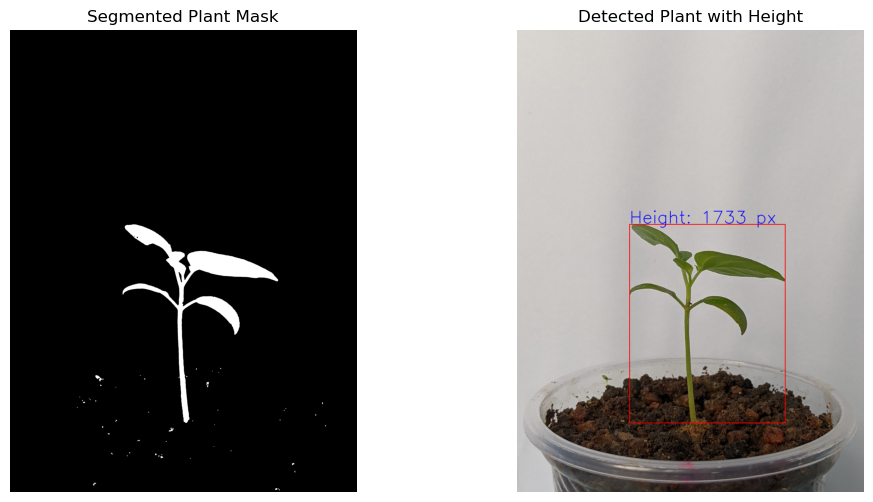

Plant Height: 1733 pixels
Plant Height: 5.76 cm


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('img/PXL_20250117_014701856.jpg')  # Replace with your image path
#image = cv2.resize(image, (900, 1200))  # Resize for better visualization

# Convert to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define HSV range for green color (adjust if needed)
lower_green = np.array([18, 62, 62])  # Lower HSV threshold
upper_green = np.array([55, 255, 186])  # Upper HSV threshold

# Create mask for green areas (plant)
mask = cv2.inRange(hsv, lower_green, upper_green)

# Apply morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Find the largest contour (assumed to be the plant)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box around the plant
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw bounding box
    result = image.copy()
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 5)

    # Display the height of the plant
    cv2.putText(result, f"Height: {h} px", (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 6)

    # Convert images to RGB for matplotlib
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('Segmented Plant Mask')
    axes[0].axis('off')
    
    axes[1].imshow(result_rgb)
    axes[1].set_title('Detected Plant with Height')
    axes[1].axis('off')
    
    plt.show()
    
    x = h * 0.00332442861383199762540813297714
    print(f"Plant Height: {h} pixels")
    print(f"Plant Height: {x:.2f} cm")
else:
    print("No plant detected!")
